### 1. Imports

In [1]:
import os
import json
import itertools
import time # Added for benchmarking
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Added for GPU optimization
import torch 

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, precision_recall_curve, f1_score
from skimage import measure

### 2. Hyperparameters and Setup

In [2]:
DATA_DIR    = Path("../data/heuristics/semantic_seg/")
LABELS_CSV  = Path("../data/images/0_data.csv") # expected: image_name,label (0/1)
OUT_CSV     = Path("../data/heuristics/occupancy_metrics.csv")
OUT_JSON    = Path("../data/heuristics/occupancy_metrics.json")

RANDOM_STATE = 144
TOLERANCE = 10 # color tolerance when matching RGB values

# color definitions (see 1_Heuristic_Self_Supervised_Segmentation notebooks)
WORM_RGB = np.array([255, 0, 0])
LEAF_RGB = np.array([0, 255, 0])
BG_RGB   = np.array([120, 120, 120])

### 3. Utils

**pct_worm_foreground**: Compute the percentage of worms relative only to the leaves, ignoring the background. This relates directly into feeding, and might helpful due to the overall high variability of the background size

In [3]:
def rgb_match(mask_arr, color_rgb, tol=TOLERANCE):
    """Return boolean mask where mask_arr RGB matches color_rgb within tol."""
    diff = np.abs(mask_arr.astype(int) - color_rgb.reshape((1, 1, 3)).astype(int))
    return np.all(diff <= tol, axis=2)


def load_mask(path):
    img = Image.open(path).convert('RGB')
    return np.array(img)


def compute_metrics_from_mask(mask_arr):
    h, w, _ = mask_arr.shape
    total = h * w
    worm_mask = rgb_match(mask_arr, WORM_RGB)
    leaf_mask = rgb_match(mask_arr, LEAF_RGB)
    bg_mask = rgb_match(mask_arr, BG_RGB)

    worm_pixels = int(worm_mask.sum())
    leaf_pixels = int(leaf_mask.sum())
    bg_pixels = int(bg_mask.sum())

    pct_worm = round(100.0 * worm_pixels / total, 3)
    pct_leaf = round(100.0 * leaf_pixels / total, 3)
    pct_bg = round(100.0 * bg_pixels / total, 3)
    pct_worm_fore = round(100.0 * (worm_pixels / (worm_pixels + leaf_pixels)), 3) if (worm_pixels + leaf_pixels) > 0 else 0.0

    # blob stats
    labeled_worms = measure.label(worm_mask, connectivity=1)
    regions = measure.regionprops(labeled_worms)
    num_worm_blobs = len(regions)
    mean_worm_blob_area = round(float(np.mean([r.area for r in regions])), 3) if regions else 0.0

    labeled_leaf = measure.label(leaf_mask, connectivity=1)
    regions_leaf = measure.regionprops(labeled_leaf)
    num_leaf_blobs = len(regions_leaf)
    mean_leaf_blob_area = round(float(np.mean([r.area for r in regions_leaf])), 3) if regions_leaf else 0.0

    return {
        "height": int(h),
        "width": int(w),
        "total_pixels": int(total),

        "worm_pixels": worm_pixels,
        "leaf_pixels": leaf_pixels,
        "bg_pixels": bg_pixels,

        "pct_worm": pct_worm,
        "pct_leaf": pct_leaf,
        "pct_bg": pct_bg,
        "pct_worm_foreground": pct_worm_fore,
        
        "num_worm_blobs": num_worm_blobs,
        "mean_worm_blob_area": mean_worm_blob_area,
        "num_leaf_blobs": num_leaf_blobs,
        "mean_leaf_blob_area": mean_leaf_blob_area,
    }


### 4. Occupancy metrics

Compute the occupancy metrics, with per class pixel count, per class area occupancy percentage, number of leaves and silkworms blobs. Then save to CSV and JSON

In [4]:
mask_files = sorted(DATA_DIR.glob('IMG_*_mask.png'))
if not mask_files:
    raise FileNotFoundError(f"No mask files found in {DATA_DIR}")

# load labels if available
if LABELS_CSV.exists():
    labels_df = pd.read_csv(LABELS_CSV)
    # expected columns: 'classificazione' (label) and 'foto' (image filename)
    if 'foto' in labels_df.columns and 'classificazione' in labels_df.columns:
        labels_map = {str(row['foto']).replace('.jpg', '_mask.png'): int(row['classificazione']) for _, row in labels_df.iterrows()}
    else:
        cols = list(labels_df.columns)
        labels_map = {str(row[cols[1]]).replace('.jpg', '_mask.png'): int(row[cols[0]]) for _, row in labels_df.iterrows()}
else:
    labels_map = {}

current = 0
total = len(mask_files)
rows = []

for p in mask_files:
    arr = load_mask(p)
    metrics = compute_metrics_from_mask(arr)
    img_name = p.name
    metrics['image_name'] = img_name
    metrics['path'] = str(p)
    # label lookup
    metrics['label'] = int(labels_map.get(img_name, -1))  # -1 means unknown, if no file loaded
    rows.append(metrics)

    print(f"\rProcessed {current}/{total}", end="", flush=True)
    current += 1

df = pd.DataFrame(rows)

# save raw metrics
df.to_csv(OUT_CSV, index=False)
with OUT_JSON.open('w') as f:
    json.dump(df.to_dict(orient='records'), f, indent=2)

# quick preview
print(f"Processed {len(df)} masks. Saved CSV to {OUT_CSV}")
print(df[['image_name','pct_worm','pct_leaf','pct_worm_foreground','label']].head())


Processed 1350/1351Processed 1351 masks. Saved CSV to ../data/heuristics/occupancy_metrics.csv
          image_name  pct_worm  pct_leaf  pct_worm_foreground  label
0  IMG_2663_mask.png    18.427    41.268               30.869      0
1  IMG_2664_mask.png    18.434    43.781               29.630      0
2  IMG_2665_mask.png    18.619    44.176               29.650      0
3  IMG_2666_mask.png    18.649    44.632               29.470      0
4  IMG_2667_mask.png    18.723    40.887               31.409      0


### 5. Data preparation

In [5]:
# keep counts and percentages in csv; use pct_worm_foreground as main feature for simple models
usable = df[df['label'] >= 0].copy()
if usable.empty:
    raise ValueError('No labeled images found. Add ../data/images/0_data.csv with image and label')

features = ['worm_pixels', 'leaf_pixels', 'pct_worm', 'pct_leaf', 'pct_worm_foreground', 'num_worm_blobs', 'mean_worm_blob_area']
X = usable[features].values
y = usable['label'].values

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)


### 6. Model definition

In [6]:
logistic = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear')

### 7. Learn ideal threshold for binary *feed / do not feed* decision

In [7]:
# use only pct_worm_foreground for thresholding and simple logistic
v_train = X_train[:, features.index('pct_worm_foreground')]
v_test = X_test[:, features.index('pct_worm_foreground')]

# fit logistic on single feature
logistic.fit(v_train.reshape(-1,1), y_train)

# test thresholds, test both directions (< and >)
candidates = np.linspace(0, 100, 1001)
best = {'f1': -1, 't': None, 'direction': None}
for t in candidates:
    pred_lt = (v_train < t).astype(int)
    pred_gt = (v_train > t).astype(int)
    f1_lt = f1_score(y_train, pred_lt)
    f1_gt = f1_score(y_train, pred_gt)
    if f1_lt > best['f1']:
        best = {'f1': f1_lt, 't': float(t), 'direction': '<'}
    if f1_gt > best['f1']:
        best = {'f1': f1_gt, 't': float(t), 'direction': '>'}

best_t = best['t']
best_dir = best['direction']
print(f"Best threshold on pct_worm_foreground (train): {best_t:.3f} direction {best_dir} with F1 {best['f1']:.3f}")

Best threshold on pct_worm_foreground (train): 55.200 direction > with F1 0.948


### 8. Plot and evaluate results

Confusion matrix (threshold):
[[107  11]
 [  6 146]]
Classification report (threshold):
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       118
           1       0.93      0.96      0.94       152

    accuracy                           0.94       270
   macro avg       0.94      0.93      0.94       270
weighted avg       0.94      0.94      0.94       270

Confusion matrix (logistic):
[[107  11]
 [  1 151]]
Classification report (logistic):
              precision    recall  f1-score   support

           0       0.99      0.91      0.95       118
           1       0.93      0.99      0.96       152

    accuracy                           0.96       270
   macro avg       0.96      0.95      0.95       270
weighted avg       0.96      0.96      0.96       270



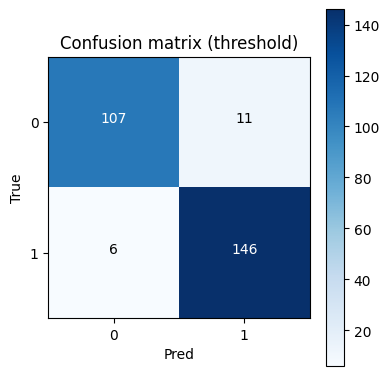

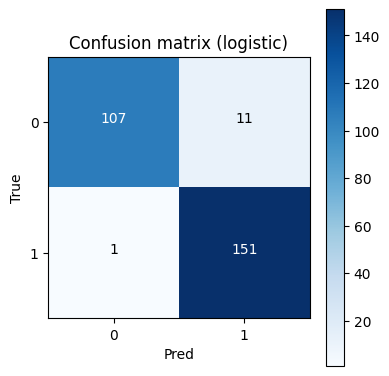

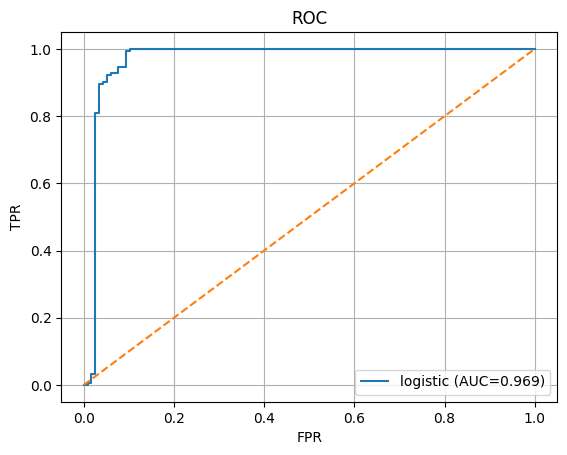

Best results near upper left corner
Logistic PR AUC: 0.921


In [ ]:
def plot_confusion(cm, labels, title):
    plt.figure(figsize=(4,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True')
    plt.xlabel('Pred')
    plt.tight_layout()

# threshold classifier on test
if best_dir == '<':
    y_pred_thresh = (v_test < best_t).astype(int)
    score_thresh = -v_test
else:
    y_pred_thresh = (v_test > best_t).astype(int)
    score_thresh = v_test

cm_thresh = confusion_matrix(y_test, y_pred_thresh)
print('Confusion matrix (threshold):')
print(cm_thresh)
print('Classification report (threshold):')
print(classification_report(y_test, y_pred_thresh))
plot_confusion(cm_thresh, labels=[0,1], title='Confusion matrix (threshold)')

# logistic on test
log_scores = logistic.predict_proba(v_test.reshape(-1,1))[:,1]
y_pred_log = (log_scores >= 0.5).astype(int)
cm_log = confusion_matrix(y_test, y_pred_log)
print('Confusion matrix (logistic):')
print(cm_log)
print('Classification report (logistic):')
print(classification_report(y_test, y_pred_log))
plot_confusion(cm_log, labels=[0,1], title='Confusion matrix (logistic)')

# ROC
plt.figure()

# logistic
fpr2, tpr2, _ = roc_curve(y_test, log_scores)
roc_auc2 = auc(fpr2, tpr2)
plt.plot(fpr2, tpr2, label=f"logistic (AUC={roc_auc2:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC')
plt.legend()
plt.grid(True)
plt.show()
print("Best results near upper left corner")

# PR AUC for logistic
precision, recall, _ = precision_recall_curve(y_test, log_scores)
pr_auc = auc(recall, precision)
print(f'Logistic PR AUC: {pr_auc:.3f}')

In [9]:
import time
import torch
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

def benchmark_inference_optimized():
    print("--- Inference Benchmark (Test Set) [High-Performance] ---")
    
    # 0. Setup GPU & optimized constants
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Running on: {DEVICE}")
    
    # Prepare reference colors for broadcasting: Shape [2, 1, 1, 3]
    # Index 0: Worm, Index 1: Leaf
    refs_np = np.stack([WORM_RGB, LEAF_RGB])
    refs = torch.tensor(refs_np, device=DEVICE, dtype=torch.int16).view(2, 1, 1, 3)
    tol = TOLERANCE
    
    # 1. Reconstruct Test Set & Pre-load to RAM
    # We load images into RAM first to measure pure INFERENCE speed, excluding Disk I/O bottleneck
    _, test_df = train_test_split(
        usable, 
        test_size=0.2, 
        stratify=usable['label'], 
        random_state=RANDOM_STATE
    )
    y_true = test_df['label'].tolist()
    test_paths = test_df['path'].tolist()
    
    print(f"Pre-loading {len(test_paths)} images to RAM...", end="")
    # List of numpy arrays (H, W, 3)
    ram_images = [np.array(Image.open(p).convert('RGB')) for p in test_paths]
    print(" Done.")
    
    # 2. Warmup
    if len(ram_images) > 0:
        dummy = torch.from_numpy(ram_images[0]).to(DEVICE).int()
        _ = (torch.abs(dummy - refs.view(2,1,1,3)) <= tol).all(dim=-1).sum()
        torch.cuda.synchronize()

    # 3. Benchmark Loop
    latencies = []
    preds_thresh = []
    preds_log = []
    
    # Pre-allocate CUDA events for precise timing
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    
    print("Running optimized inference...", end="")
    
    for img_np in ram_images:
        # Start Timer
        start_event.record()
        
        # A. Transfer to GPU (Included in inference time as inputs must move to device)
        # Use non_blocking=True if pinned memory, but standard here is fine
        img_tensor = torch.from_numpy(img_np).to(DEVICE)
        
        # B. Optimized Feature Extraction
        # Cast to int16 to avoid overflow, view as [1, H, W, 3]
        img_int = img_tensor.int().unsqueeze(0) 
        
        # Vectorized Diff: [2, 1, 1, 3] - [1, H, W, 3] -> Broadcasts to [2, H, W, 3]
        # Calculate diff, check tolerance, and sum in one pass per channel
        # Result: [2] (Count of Worm pixels, Count of Leaf pixels)
        counts = (torch.abs(img_int - refs) <= tol).all(dim=-1).sum(dim=(1, 2))
        
        # Move small scalar result to CPU (One synchronization point)
        w_px, l_px = counts.tolist()
        
        # C. Logic & Classification (CPU light operations)
        denom = w_px + l_px
        val = 100.0 * (w_px / denom) if denom > 0 else 0.0
        
        # Threshold
        if best_dir == '<':
            p_t = 1 if val < best_t else 0
        else:
            p_t = 1 if val > best_t else 0
            
        # Logistic
        p_l = int(logistic.predict([[val]])[0])
        
        # Stop Timer
        end_event.record()
        end_event.synchronize() # Wait for this image to finish
        
        latencies.append(start_event.elapsed_time(end_event)) # Returns ms
        preds_thresh.append(p_t)
        preds_log.append(p_l)
        
    print(" Done.")

    # 4. Metrics Reporting
    def print_metrics(name, y_t, y_p):
        print(f"\n--- {name} Metrics ---")
        cm = confusion_matrix(y_t, y_p, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        
        acc = (tp + tn) / (tp + tn + fp + fn)
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
        
        # New Metrics
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        fpr = fp / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"Accuracy   : {acc:.4f}")
        print(f"Precision  : {prec:.4f}")
        print(f"Recall     : {rec:.4f}")
        print(f"F1         : {f1:.4f}")
        print(f"Specificity: {spec:.4f}")
        print(f"FPR        : {fpr:.4f}")

    print_metrics("Threshold Classifier", y_true, preds_thresh)
    print_metrics("Logistic Regression", y_true, preds_log)
    
    print("-" * 30)
    print("--- Efficiency Metrics ---")
    
    avg_lat = np.mean(latencies)
    std_lat = np.std(latencies)
    total_time_compute = np.sum(latencies) / 1000.0 # seconds
    
    print(f"Time (Test Set Compute): {total_time_compute:.4f} s ({len(ram_images)} images)")
    print(f"Throughput             : {1000.0 / avg_lat:.2f} img/s")
    print(f"Latency (Single Image) : {avg_lat:.2f} ms ± {std_lat:.2f} ms")

benchmark_inference_optimized()

--- Inference Benchmark (Test Set) [High-Performance] ---
Running on: cuda
Pre-loading 270 images to RAM... Done.
Running optimized inference... Done.

--- Threshold Classifier Metrics ---
Accuracy   : 0.9370
Precision  : 0.9299
Recall     : 0.9605
F1         : 0.9450
Specificity: 0.9068
FPR        : 0.0932

--- Logistic Regression Metrics ---
Accuracy   : 0.9556
Precision  : 0.9321
Recall     : 0.9934
F1         : 0.9618
Specificity: 0.9068
FPR        : 0.0932
------------------------------
--- Efficiency Metrics ---
Time (Test Set Compute): 0.7711 s (270 images)
Throughput             : 350.15 img/s
Latency (Single Image) : 2.86 ms ± 0.08 ms
